# Notebook 01 — EDA
## STOP 1 — Load & Inspect

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = ROOT / "data" / "raw" / "winequality-red.csv"
CHARTS = ROOT / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    df = pd.read_csv(url, sep=";")
    df.to_csv(DATA_PATH, sep=";", index=False)
else:
    df = pd.read_csv(DATA_PATH, sep=";")

print("shape:", df.shape)
print("\ndtypes:\n", df.dtypes)
print("\nsummary:\n", df.describe())
print("\nquality counts:\n", df["quality"].value_counts().sort_index())

shape: (1599, 12)

dtypes:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

summary:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.60000

## STOP 2 — Class Distribution & Binning Strategy

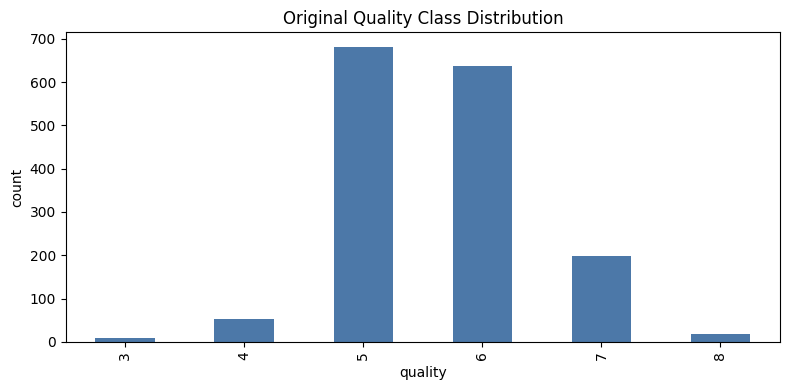

quality_class
0      63
1    1319
2     217
Name: count, dtype: int64


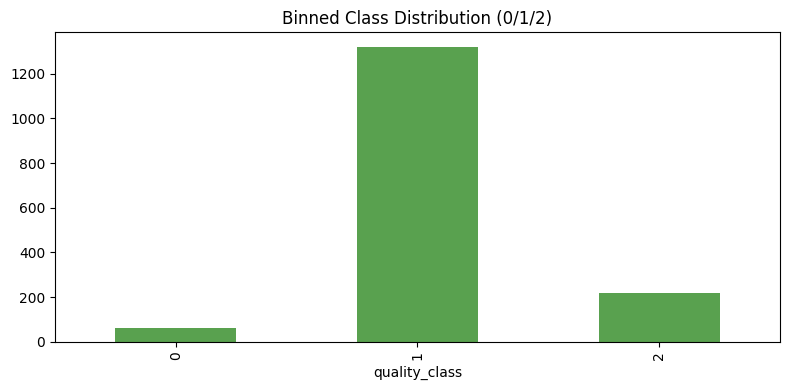

In [2]:
plt.figure(figsize=(8,4))
ax = df["quality"].value_counts().sort_index().plot(kind="bar", color="#4C78A8")
ax.set_title("Original Quality Class Distribution")
ax.set_xlabel("quality")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(CHARTS / "quality_distribution_original.png", dpi=180)
plt.show()

# Bin classes: 3,4->0 | 5,6->1 | 7,8,9->2
def bin_quality(q):
    if q <= 4:
        return 0
    if q <= 6:
        return 1
    return 2

df["quality_class"] = df["quality"].apply(bin_quality)
print(df["quality_class"].value_counts().sort_index())

plt.figure(figsize=(8,4))
ax = df["quality_class"].value_counts().sort_index().plot(kind="bar", color="#59A14F")
ax.set_title("Binned Class Distribution (0/1/2)")
plt.tight_layout()
plt.savefig(CHARTS / "quality_distribution_binned.png", dpi=180)
plt.show()

## STOP 3 — Feature Distributions per Class

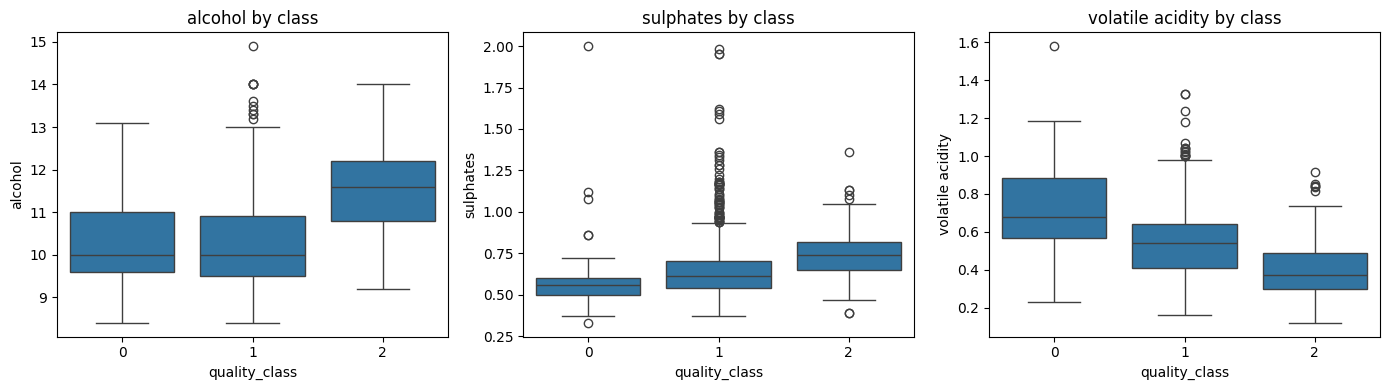

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["alcohol", "sulphates", "volatile acidity"]):
    sns.boxplot(data=df, x="quality_class", y=col, ax=ax)
    ax.set_title(f"{col} by class")
plt.tight_layout()
plt.savefig(CHARTS / "feature_boxplots_by_class.png", dpi=180)
plt.show()